In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. CHARGEMENT ET NETTOYAGE (Base existante) ---
df = pd.read_csv("data/divorces_2000-2015_translated.csv")

# Correction des dates
def clean_date_century(x):
    if pd.isnull(x): return pd.NaT
    if x.year > 2020: return x - pd.DateOffset(years=100)
    return x

date_cols = ['DOB_partner_man', 'DOB_partner_woman', 'Date_of_marriage']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format='%d/%m/%y', errors='coerce')
    df[col] = df[col].apply(clean_date_century)

# Feature Engineering de base
df['Age_at_marriage_man'] = (df['Date_of_marriage'] - df['DOB_partner_man']).dt.days / 365.25
df['Age_at_marriage_woman'] = (df['Date_of_marriage'] - df['DOB_partner_woman']).dt.days / 365.25
df['Age_diff'] = abs(df['Age_at_marriage_man'] - df['Age_at_marriage_woman'])
df['Income_Total'] = df['Monthly_income_partner_man_peso'].fillna(0) + df['Monthly_income_partner_woman_peso'].fillna(0)
df['Num_Children'] = df['Num_Children'].fillna(0) # On garde les enfants pour le clustering

# Filtrage basique
df_clean = df.dropna(subset=['Age_at_marriage_man', 'Age_at_marriage_woman', 'Type_of_divorce']).copy()

# ==============================================================================
# EXPÉRIENCE 1 : PRÉDIRE LE TYPE DE DIVORCE (Conflictuel vs Amiable)
# ==============================================================================
print("\n--- EXPÉRIENCE 1 : PRÉDICTION DU TYPE DE DIVORCE ---")

# 1. Encodage de la cible (Voluntario vs Necesario)
le = LabelEncoder()
df_clean['Type_Target'] = le.fit_transform(df_clean['Type_of_divorce'])
print(f"Classes : {le.classes_}")
# Généralement : 0 = Necesario (Conflictuel), 1 = Voluntario (Amiable)

# 2. Sélection des Features
# On retire la durée du divorce car on veut prédire le type *avant* que ça arrive
features_classif = ['Age_at_marriage_man', 'Age_at_marriage_woman', 'Age_diff',
                    'Income_Total', 'Num_Children']
X = df_clean[features_classif]
y = df_clean['Type_Target']

# 3. Modèle (Régression Logistique pour l'interprétabilité)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

clf = LogisticRegression(random_state=42)
clf.fit(X_train_s, y_train)
y_pred = clf.predict(X_test_s)

print(classification_report(y_test, y_pred))

# 4. Interprétation des coefficients (Qu'est-ce qui cause le conflit ?)
coeffs = pd.DataFrame({'Feature': features_classif, 'Coeff': clf.coef_[0]})
coeffs = coeffs.sort_values(by='Coeff', ascending=False)
print("\nFacteurs favorisant le divorce 'Voluntario' (Coeff positif) vs 'Necesario' (Négatif):")
print(coeffs)




--- EXPÉRIENCE 1 : PRÉDICTION DU TYPE DE DIVORCE ---
Classes : ['Necesario' 'Voluntario']
              precision    recall  f1-score   support

           0       0.63      0.51      0.57       402
           1       0.64      0.74      0.69       473

    accuracy                           0.64       875
   macro avg       0.63      0.63      0.63       875
weighted avg       0.64      0.64      0.63       875


Facteurs favorisant le divorce 'Voluntario' (Coeff positif) vs 'Necesario' (Négatif):
                 Feature     Coeff
0    Age_at_marriage_man  0.095941
1  Age_at_marriage_woman  0.034664
2               Age_diff  0.030695
3           Income_Total -0.042969
4           Num_Children -0.616989



--- EXPÉRIENCE 2 : CLUSTERING DES PROFILS DE COUPLES ---

Profils moyens par Cluster :
         Age_at_marriage_man  Income_Total  Num_Children  Marriage_duration
Cluster                                                                    
0                  24.609136  1.295791e+04      2.159446          19.285199
1                  29.500342  3.159242e+06      2.000000          18.000000
2                  28.927920  1.118753e+04      0.485493           5.972921


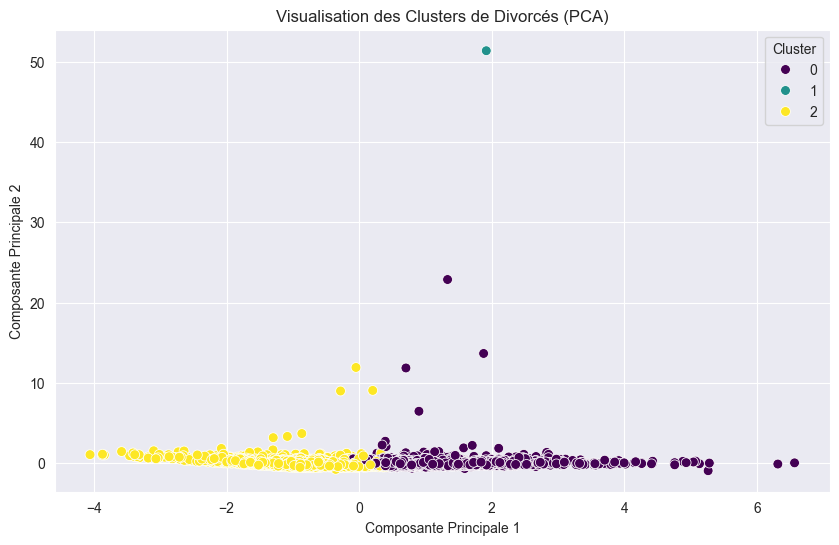

In [17]:
# ==============================================================================
# EXPÉRIENCE 2 : CLUSTERING (Quels sont les profils types ?)
# ==============================================================================
print("\n--- EXPÉRIENCE 2 : CLUSTERING DES PROFILS DE COUPLES ---")

# 1. Sélection des données pour le clustering
# On ajoute la durée du mariage pour voir si cela crée des groupes distincts
features_clust = ['Age_at_marriage_man', 'Income_Total', 'Num_Children', 'Marriage_duration']
X_clust = df_clean[features_clust].dropna()

# 2. Scaling (Très important pour K-Means)
scaler_clust = StandardScaler()
X_clust_s = scaler_clust.fit_transform(X_clust)

# 3. K-Means (Essayons 3 groupes)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_clust_s)
X_clust['Cluster'] = clusters

# 4. Analyse des Clusters (Moyennes par groupe)
print("\nProfils moyens par Cluster :")
print(X_clust.groupby('Cluster').mean())

# 5. Visualisation 2D avec PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clust_s)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis', s=50)
plt.title("Visualisation des Clusters de Divorcés (PCA)")
plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.legend(title='Cluster')
plt.show()

Nombre de couples analysés après nettoyage complet : 4241

--- NOUVEAUX PROFILS TYPES (SANS MILLIONNAIRE) ---
         Age_at_marriage_man  Income_Total  Num_Children  Marriage_duration
Cluster                                                                    
0                  24.665441  10664.473066      2.241713          20.418508
1                  25.674160   8013.894389      0.587135           6.216697
2                  39.140793  20912.587288      0.504160           7.008319


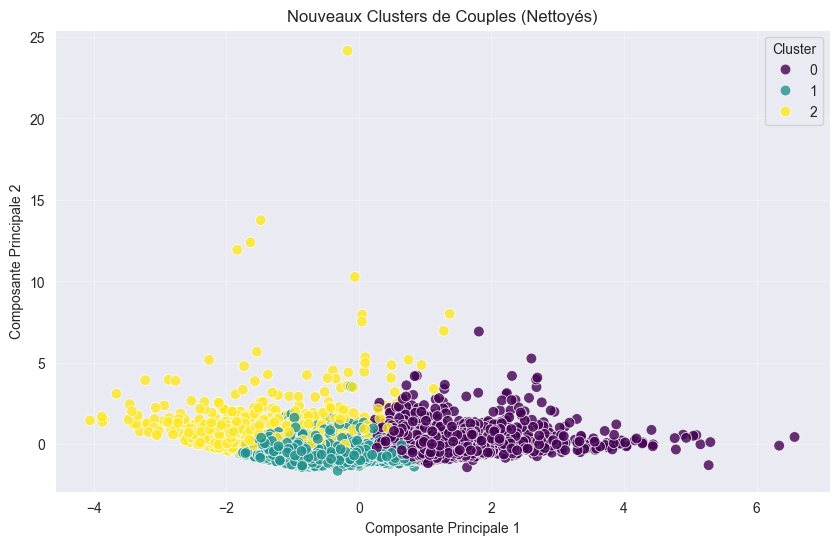

C:\Users\Léon\AppData\Local\Temp\ipykernel_33812\1038643071.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Num_Children', data=df_refined, ax=axes[0], palette="viridis")
C:\Users\Léon\AppData\Local\Temp\ipykernel_33812\1038643071.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Marriage_duration', data=df_refined, ax=axes[1], palette="viridis")
C:\Users\Léon\AppData\Local\Temp\ipykernel_33812\1038643071.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Age_at_marriage_man', data=df

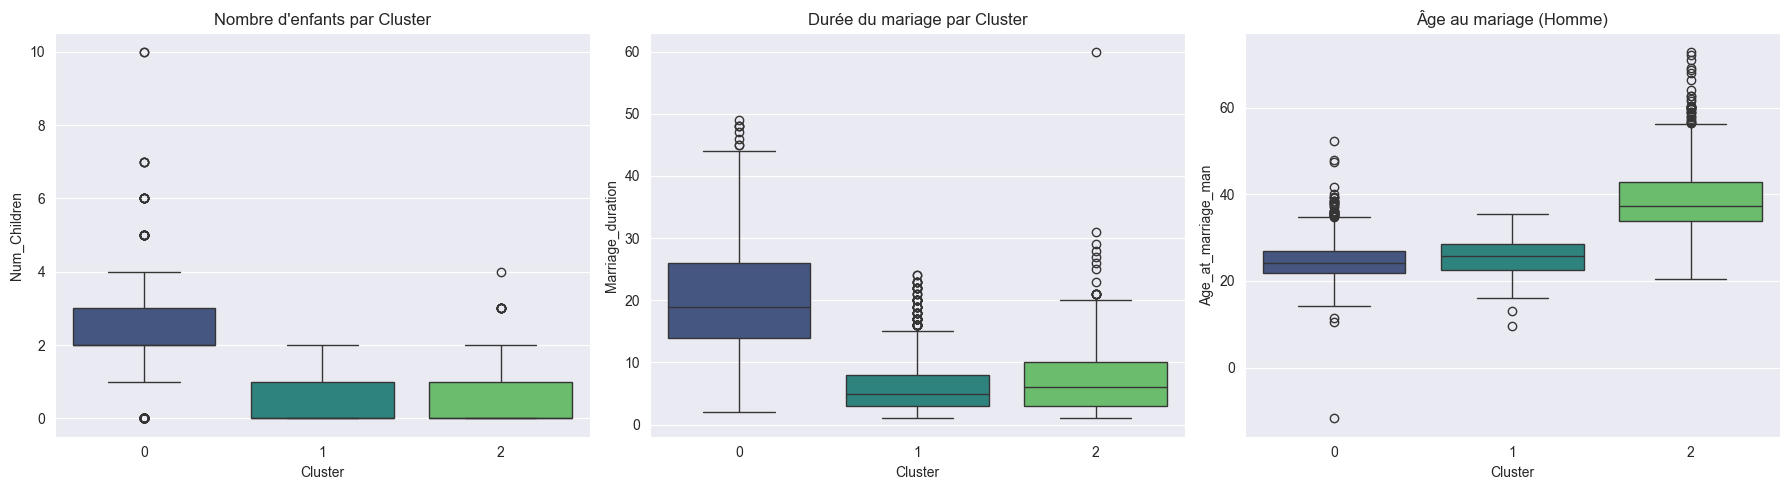

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# --- 1. PRÉPARATION (On reprend la base nettoyée) ---
# On suppose que 'df_clean' existe déjà (issu du code précédent).
# Si ce n'est pas le cas, relancez le bloc de nettoyage précédent.

# FILTRAGE DE L'OUTLIER (Revenus > 500k)
df_refined = df_clean[df_clean['Income_Total'] < 500000].copy()

# --- CORRECTION DE L'ERREUR ICI ---
# On définit les variables qu'on veut utiliser
features_clust = ['Age_at_marriage_man', 'Income_Total', 'Num_Children', 'Marriage_duration']

# IMPORTANT : On supprime les lignes où il manque une info (ex: durée du mariage inconnue)
# C'est ce qui causait le ValueError
df_refined = df_refined.dropna(subset=features_clust)

print(f"Nombre de couples analysés après nettoyage complet : {len(df_refined)}")

# --- 2. CLUSTERING SUR DONNÉES FILTRÉES ---

X_clust = df_refined[features_clust]

# Scaling
scaler_clust = StandardScaler()
X_clust_s = scaler_clust.fit_transform(X_clust)

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_clust_s)
df_refined['Cluster'] = clusters

# --- 3. ANALYSE DES NOUVEAUX PROFILS ---
print("\n--- NOUVEAUX PROFILS TYPES (SANS MILLIONNAIRE) ---")
print(df_refined.groupby('Cluster')[features_clust].mean())

# --- 4. VISUALISATION PCA ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clust_s)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis', s=60, alpha=0.8)
plt.title("Nouveaux Clusters de Couples (Nettoyés)")
plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

# --- 5. VISUALISATION INTERPRÉTATIVE (BOXPLOTS) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='Cluster', y='Num_Children', data=df_refined, ax=axes[0], palette="viridis")
axes[0].set_title('Nombre d\'enfants par Cluster')

sns.boxplot(x='Cluster', y='Marriage_duration', data=df_refined, ax=axes[1], palette="viridis")
axes[1].set_title('Durée du mariage par Cluster')

sns.boxplot(x='Cluster', y='Age_at_marriage_man', data=df_refined, ax=axes[2], palette="viridis")
axes[2].set_title('Âge au mariage (Homme)')

plt.tight_layout()
plt.show()

Mapping des types de divorce : {'Necesario': np.int64(0), 'Voluntario': np.int64(1)}

--- PROFILS TYPES (STATISTIQUES) ---
         Marriage_duration  Num_Children  Income_Total  Age_at_marriage_man  \
Cluster                                                                       
0                15.985862      1.826579  14311.637606            24.781489   
1                 5.798896      0.380748  13049.688841            26.681138   
2                 8.225873      0.694045  14809.238111            39.818082   

        Type_of_divorce  
Cluster                  
0             Necesario  
1            Voluntario  
2            Voluntario  


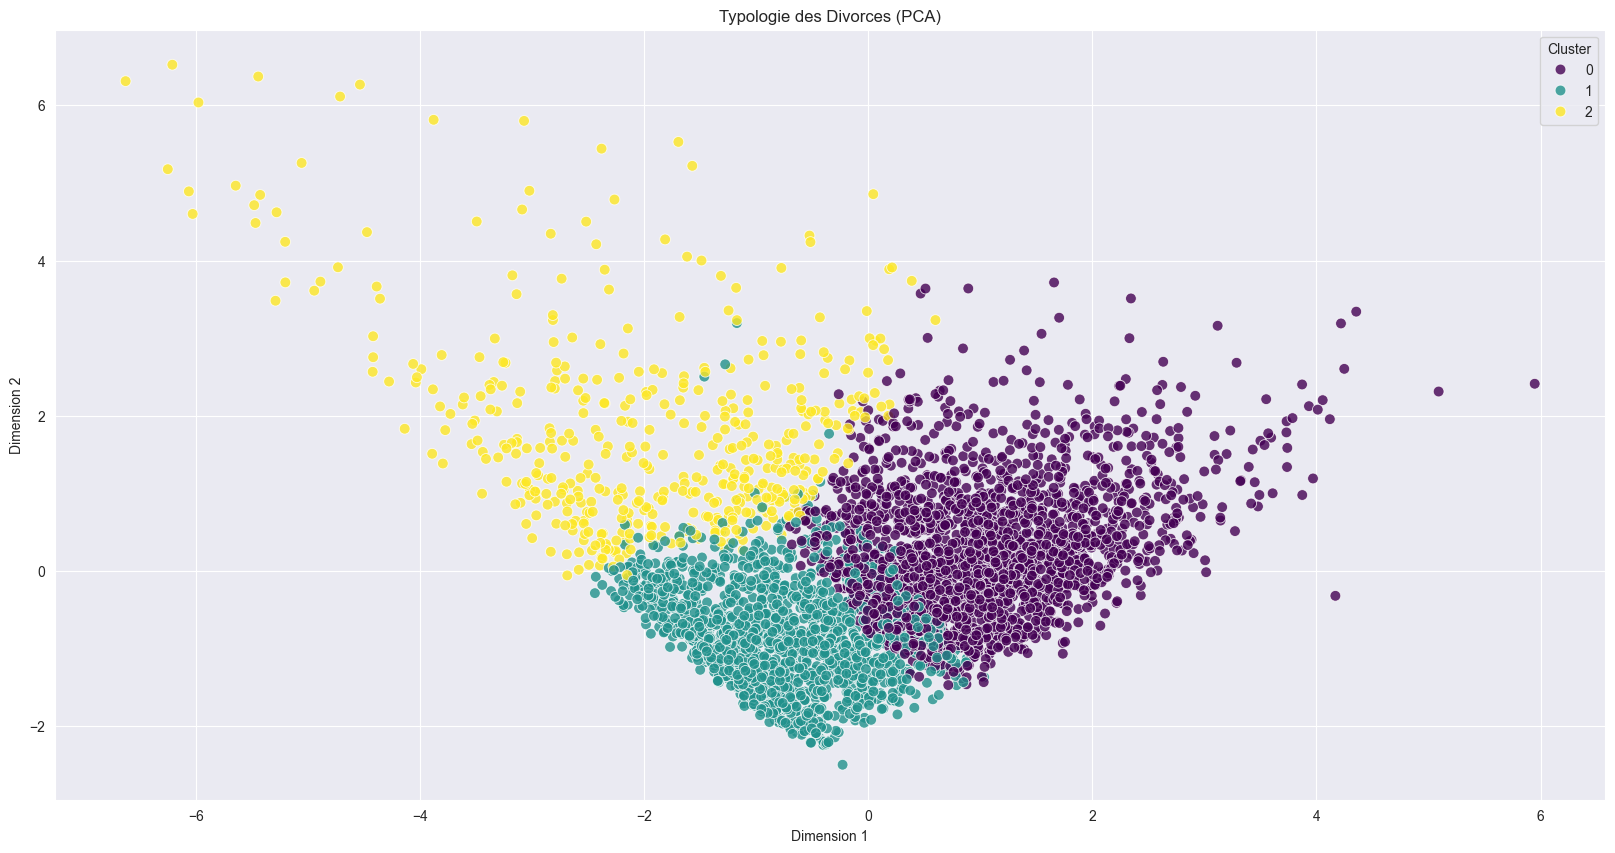

In [23]:
def clean_date_century(x):
    if pd.isnull(x): return pd.NaT
    if x.year > 2020: return x - pd.DateOffset(years=100)
    return x

for col in ['DOB_partner_man', 'DOB_partner_woman', 'Date_of_marriage']:
    df[col] = pd.to_datetime(df[col], format='%d/%m/%y', errors='coerce').apply(clean_date_century)

df['Age_at_marriage_man'] = (df['Date_of_marriage'] - df['DOB_partner_man']).dt.days / 365.25
df['Age_at_marriage_woman'] = (df['Date_of_marriage'] - df['DOB_partner_woman']).dt.days / 365.25
df['Age_diff'] = abs(df['Age_at_marriage_man'] - df['Age_at_marriage_woman'])
df['Income_Total'] = df['Monthly_income_partner_man_peso'].fillna(df['Monthly_income_partner_man_peso'].median()) + \
                     df['Monthly_income_partner_woman_peso'].fillna(df['Monthly_income_partner_woman_peso'].median())
df['Num_Children'] = df['Num_Children'].fillna(0)

# --- PRÉPARATION SPÉCIFIQUE ---
# On supprime les lignes où le type est inconnu
df = df.dropna(subset=['Type_of_divorce'])

# ASTUCE : On garde la colonne texte originale ET on crée une version encodée pour le calcul
le = LabelEncoder()
df['Type_Code'] = le.fit_transform(df['Type_of_divorce'])
# On imprime le mapping pour être sûr de l'ordre
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Mapping des types de divorce : {mapping}")

# Sélection des features pour le CALCUL (uniquement numérique)
features_numeric = ['Marriage_duration', 'Type_Code', 'Num_Children', 'Income_Total', 'Age_at_marriage_man', 'Age_diff']

# Nettoyage final des NaNs sur ces features
df_clean = df.dropna(subset=features_numeric).copy()
df_clean = df_clean[df_clean['Income_Total'] < 300000].copy()

# --- 2. CLUSTERING ---
X = df_clean[features_numeric]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

# --- 3. RÉSULTATS AVEC VRAIS NOMS ---
# Pour l'affichage, on utilise la colonne texte 'Type_of_divorce' d'origine
# On calcule le "Mode" (la valeur la plus fréquente) pour le type de divorce par cluster
print("\n--- PROFILS TYPES (STATISTIQUES) ---")
summary = df_clean.groupby('Cluster').agg({
    'Marriage_duration': 'mean',
    'Num_Children': 'mean',
    'Income_Total': 'mean',
    'Age_at_marriage_man': 'mean',
    'Type_of_divorce': lambda x: x.mode()[0]  # Affiche le type le plus fréquent (ex: "Necesario")
})
print(summary)

# --- 4. VISUALISATIONS ---

# Figure A : PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(20, 10))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df_clean['Cluster'], palette='viridis', s=60, alpha=0.8)
plt.title("Typologie des Divorces (PCA)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend(title='Cluster')
plt.show()



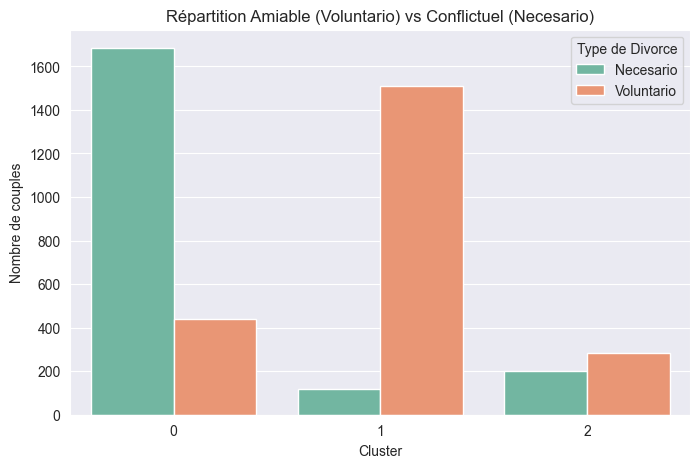

In [20]:
# Figure B : Répartition des Types de Divorce (AVEC LES VRAIS NOMS)
plt.figure(figsize=(8, 5))
# Ici on utilise 'Type_of_divorce' (texte) pour la légende, c'est plus clair
sns.countplot(x='Cluster', hue='Type_of_divorce', data=df_clean, palette='Set2')
plt.title("Répartition Amiable (Voluntario) vs Conflictuel (Necesario)")
plt.ylabel("Nombre de couples")
plt.legend(title='Type de Divorce')
plt.show()